In [1]:
#Install and Setup Kaggle API
%pip -q install kaggle



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/nyeinchanaung/Downloads/ML:CP Project/cp-env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "data"

#load the metadata set
metadata_path = os.path.join(DATA_DIR, "metadata - standardized.csv")
df = pd.read_csv(metadata_path)

#see the basic info of the dataset

print("Shape:", df.shape)
df.head()

df.info()

df.columns.tolist()
df["types"].value_counts()




Shape: (12449, 48)
<class 'pandas.DataFrame'>
RangeIndex: 12449 entries, 0 to 12448
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   names                     12449 non-null  str    
 1   types                     12449 non-null  int64  
 2   type_expanded             6577 non-null   str    
 3   isColor                   12449 non-null  int64  
 4   original_name             12449 non-null  str    
 5   patient_id                488 non-null    str    
 6   fundus                    12449 non-null  str    
 7   fundus_od_seg             3103 non-null   str    
 8   fundus_oc_seg             3103 non-null   str    
 9   bv_seg                    462 non-null    str    
 10  artery_seg                22 non-null     str    
 11  vein_seg                  22 non-null     str    
 12  oct                       79 non-null     str    
 13  oct_oc_seg                45 non-null     str    
 14

types
 0    7549
 1    4767
-1     133
Name: count, dtype: int64

Binary class distribution:
types
0    7549
1    4767
Name: count, dtype: int64

Percentage:
types
0    61.29
1    38.71
Name: proportion, dtype: float64


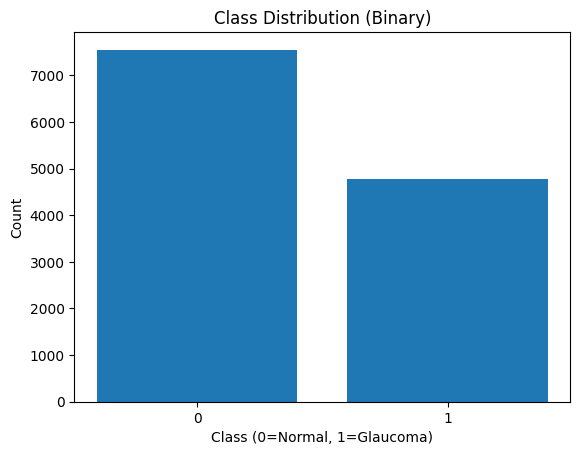

In [3]:
#clean Labels
df = df[df["types"] != -1].copy()

print("Binary class distribution:")
print(df["types"].value_counts())
print("\nPercentage:")
print((df["types"].value_counts(normalize=True) * 100).round(2))

#visualize the class distribution
counts = df["types"].value_counts().sort_index()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution (Binary)")
plt.xlabel("Class (0=Normal, 1=Glaucoma)")
plt.ylabel("Count")
plt.show()



In [4]:
#Data set Source distribution
[c for c in df.columns if "dataset" in c.lower() or "source" in c.lower()]
for col in df.columns:
    print(col)



names
types
type_expanded
isColor
original_name
patient_id
fundus
fundus_od_seg
fundus_oc_seg
bv_seg
artery_seg
vein_seg
oct
oct_oc_seg
oct_od_seg
sex
gender
age
eye
sbp
dbp
hr
iop
vcdr
Unnamed: 24
notchI_present
notchS_present
notchN_present
notchT_present
expert1_grade
expert2_grade
expert3_grade
expert4_grade
expert5_grade
cdr_avg
cdr_expert1
cdr_expert2
cdr_expert3
cdr_expert4
refractive_dioptre_1
refractive_dioptre_2
refractive_astigmatism
phakic_or_pseudophakic
iop_perkins
iop_pneumatic
pachymetry
axial_length
visual_field_mean_defect


Total samples: 12316
Unique patients: 210
Average images per patient: 2.0
Max images per patient: 2


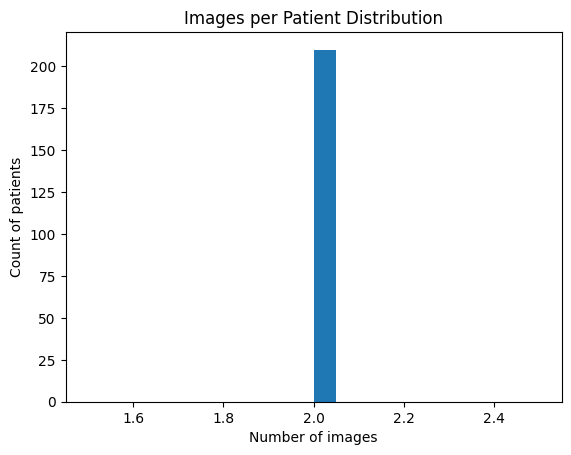

Unique patient_id: 210
Unique original_name: 12096


patient_id
PAPILA-4     2
PAPILA-5     2
PAPILA-10    2
PAPILA-13    2
PAPILA-14    2
PAPILA-15    2
PAPILA-16    2
PAPILA-19    2
PAPILA-20    2
PAPILA-21    2
Name: count, dtype: int64

In [5]:
#patiant level analysis

print("Total samples:", len(df))
print("Unique patients:", df["patient_id"].nunique())

images_per_patient = df.groupby("patient_id").size()
print("Average images per patient:", images_per_patient.mean())
print("Max images per patient:", images_per_patient.max())

#visualize images per patient distribution
plt.hist(images_per_patient, bins=20)
plt.title("Images per Patient Distribution")
plt.xlabel("Number of images")
plt.ylabel("Count of patients")
plt.show()

#diagnosis distribution
df[["patient_id", "original_name"]].head(20)
df["original_name"].nunique()
df.groupby("patient_id")["original_name"].nunique().head()

print("Unique patient_id:", df["patient_id"].nunique())
print("Unique original_name:", df["original_name"].nunique())

df["patient_id"].value_counts().head(10)







There are only 210 unique patient IDs.
Each appears twice → likely left/right eye.
So:
210 patients × 2 eyes = 420 images
But total samples = 12,316.
Therefore:
patient_id exists only for one specific dataset (likely PAPILA dataset).Other datasets probably have missing or blank patient_id.Or reuse different ID format.

Critical Insight
This means:
CANNOT do proper patient-level splitting globally.only have patient grouping for a small subset.Most datasets are image-level only.

Due to the multi-source nature of the dataset and incomplete global patient identifiers, splitting was performed at the image level.

In [6]:
#check dataset source distribution
[c for c in df.columns if "dataset" in c.lower() or "source" in c.lower()]
df["names"].head()
df["original_name"].head(20)

df["eye"].value_counts()
pd.crosstab(df["eye"], df["types"], normalize="index") * 100








types,0,1
eye,,
OD,89.563636,10.436364
OS,88.892770,11.107230


In [7]:
print("Missing fundus:", df["fundus"].isna().sum())
for col in ["fundus_od_seg", "fundus_oc_seg", "bv_seg"]:
    print(col, round(df[col].notna().mean()*100,2))


Missing fundus: 0
fundus_od_seg 24.64
fundus_oc_seg 24.64
bv_seg 3.75


Every sample has a fundus image.

Baseline (Option A-Binary glaucoma classification using only fundus RGB images) is fully feasible.

~25% of samples have optic disc/cup masks

~3.7% have vessel masks

So:

❌ Option B - Improve classification by adding segmentation information cannot use full dataset
❌ You would need to filter to only 25% of data
❌ That reduces sample size dramatically

In [12]:
import sys, subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python"])

import cv2
print(cv2.__version__)


4.13.0


In [13]:
import os, zipfile
import numpy as np
import cv2

DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "multichannel-glaucoma-benchmark-dataset.zip")

zf = zipfile.ZipFile(ZIP_PATH, "r")
zip_names = set(zf.namelist())

def read_image_from_zip(rel_path: str):
    if rel_path is None or str(rel_path) == "nan":
        return None
    rel_path = str(rel_path).replace("\\", "/").lstrip("./")
    if rel_path not in zip_names:
        return None

    data = zf.read(rel_path)
    arr = np.frombuffer(data, dtype=np.uint8)
    img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


In [17]:
import os, zipfile
import numpy as np
import cv2

DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "multichannel-glaucoma-benchmark-dataset.zip")

zf = zipfile.ZipFile(ZIP_PATH, "r")
zip_list = zf.namelist()
zip_set = set(zip_list)

# Map basename -> full paths inside zip (some names may repeat)
from collections import defaultdict
base_to_paths = defaultdict(list)
for name in zip_list:
    base_to_paths[os.path.basename(name)].append(name)

def resolve_zip_path(rel_path: str):
    """Resolve metadata path to an actual path inside the zip."""
    if rel_path is None or str(rel_path) == "nan":
        return None

    rel_path = str(rel_path).replace("\\", "/").lstrip("./")

    # 1) Direct match
    if rel_path in zip_set:
        return rel_path

    # 2) Try removing leading "data/" if metadata includes it
    if rel_path.startswith("data/") and rel_path[5:] in zip_set:
        return rel_path[5:]

    # 3) Try basename match (common when metadata stores only filename)
    base = os.path.basename(rel_path)
    candidates = base_to_paths.get(base, [])
    if len(candidates) == 1:
        return candidates[0]
    elif len(candidates) > 1:
        # Prefer paths containing 'fundus' if any
        fundus_like = [c for c in candidates if "fundus" in c.lower()]
        return fundus_like[0] if fundus_like else candidates[0]

    return None

def read_image_from_zip(rel_path: str):
    """Return RGB image array or None."""
    zpath = resolve_zip_path(rel_path)
    if zpath is None:
        return None

    data = zf.read(zpath)
    arr = np.frombuffer(data, dtype=np.uint8)
    img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

#Debugging: find out why first sample fails to load
p = df["fundus"].dropna().iloc[0]
print("Metadata fundus path:", p)

zpath = resolve_zip_path(p)
print("Resolved zip path:", zpath)

if zpath is None:
    # Show a few fundus-like paths to help confirm structure
    fundus_candidates = [n for n in zip_list if "fundus" in n.lower()]
    print("Example fundus paths in zip:", fundus_candidates[:10])
else:
    img = read_image_from_zip(p)
    print("Decoded:", img is not None)
    if img is not None:
        print("Shape:", img.shape)

img = read_image_from_zip(p)
if img is None:
    print("Failed to read image:", p)
else:
    print(img.shape)





Metadata fundus path: /full-fundus/OIA-ODIR-TEST-OFFLINE-1.png
Resolved zip path: full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-1.png
Decoded: True
Shape: (512, 512, 3)
(512, 512, 3)


In [ ]:
#Setup paths + load metadata

import os, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "multichannel-glaucoma-benchmark-dataset.zip")
META_PATH = os.path.join(DATA_DIR, "metadata - standardized.csv")

df = pd.read_csv(META_PATH)

# Binary task: remove suspected (-1)
df = df[df["types"] != -1].copy()

print("Samples:", len(df))
print("Class %:\n", (df["types"].value_counts(normalize=True)*100).round(2))
df.head()


Samples: 12316
Class %:
 types
0    61.29
1    38.71
Name: proportion, dtype: float64


,names,types,type_expanded,isColor,original_name,patient_id,fundus,fundus_od_seg,fundus_oc_seg,bv_seg,...,cdr_expert4,refractive_dioptre_1,refractive_dioptre_2,refractive_astigmatism,phakic_or_pseudophakic,iop_perkins,iop_pneumatic,pachymetry,axial_length,visual_field_mean_defect
0,OIA-ODIR-TEST-OFFLINE-1,0,NaN,1,1029_right.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-1.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OIA-ODIR-TEST-OFFLINE-2,0,NaN,1,1049_left.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-2.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OIA-ODIR-TEST-OFFLINE-4,0,NaN,1,1128_left.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-4.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OIA-ODIR-TEST-OFFLINE-5,0,NaN,1,1179_right.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-5.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OIA-ODIR-TEST-OFFLINE-6,0,NaN,1,1180_left.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-6.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
#zip image reader
zf = zipfile.ZipFile(ZIP_PATH, "r")
zip_names = set(zf.namelist())  # for fast existence checks

def read_image_from_zip(rel_path: str):
    """
    Read an image file from inside the Kaggle zip using its relative path
    from the metadata column (e.g., df['fundus']).
    Returns RGB image as np.ndarray (H,W,3) or None if missing/unreadable.
    """
    if pd.isna(rel_path):
        return None

    rel_path = str(rel_path)

    # Some metadata paths may omit the top folder; we try direct match first.
    if rel_path not in zip_names:
        # Try common fixes (only if needed)
        candidates = [
            rel_path.lstrip("./"),
            rel_path.replace("\\", "/"),
        ]
        found = next((c for c in candidates if c in zip_names), None)
        if found is None:
            return None
        rel_path = found

    data = zf.read(rel_path)
    arr = np.frombuffer(data, dtype=np.uint8)
    img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb


In [22]:
import os, zipfile
import numpy as np
import cv2

DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "multichannel-glaucoma-benchmark-dataset.zip")

zf = zipfile.ZipFile(ZIP_PATH, "r")
zip_list = zf.namelist()
zip_set = set(zip_list)

# quick helper: try a list of candidate internal paths
def resolve_zip_path(p: str):
    if p is None or str(p) == "nan":
        return None

    p = str(p).replace("\\", "/").strip()

    # normalize: remove leading slash
    p0 = p.lstrip("/").lstrip("./")

    # common candidates (because some zips have nested folders)
    candidates = [
        p0,                                # full-fundus/xxx.png
        p0.lstrip("/"),                    # just in case
        "data/" + p0,                      # data/full-fundus/xxx.png
        "full-fundus/" + p0.split("/")[-1],# full-fundus/<basename>
        "full-fundus/full-fundus/" + p0.split("/")[-1],  # full-fundus/full-fundus/<basename>
        "full-fundus/" + p0,               # full-fundus/full-fundus/xxx.png or similar
        "full-fundus/full-fundus/" + p0,   # if p0 already includes full-fundus/
    ]

    for c in candidates:
        c = c.replace("//", "/")
        if c in zip_set:
            return c

    return None


def read_image_from_zip(rel_path: str):
    zpath = resolve_zip_path(rel_path)
    if zpath is None:
        return None
    data = zf.read(zpath)
    arr = np.frombuffer(data, dtype=np.uint8)
    img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)




In [24]:
p = df["fundus"].dropna().iloc[0]
print("Metadata path:", p)
print("Resolved zip path:", resolve_zip_path(p))

img = read_image_from_zip(p)
print("Loaded?", img is not None)
if img is not None:
    print("Shape:", img.shape)
resolved = df["fundus"].dropna().apply(resolve_zip_path)
print("Resolved %:", (resolved.notna().mean() * 100).round(2))
print("Missing count:", resolved.isna().sum())
resolved.head(10)


Metadata path: /full-fundus/OIA-ODIR-TEST-OFFLINE-1.png
Resolved zip path: full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-1.png
Loaded? True
Shape: (512, 512, 3)
Resolved %: 100.0
Missing count: 0


0    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
1    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
2    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
3    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
4    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
5    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
6    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
7    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
8    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
9    full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-...
Name: fundus, dtype: str

Unique heights: [512]
Unique widths: [512]


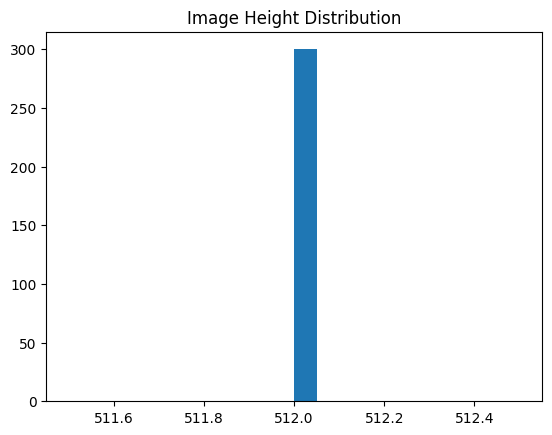

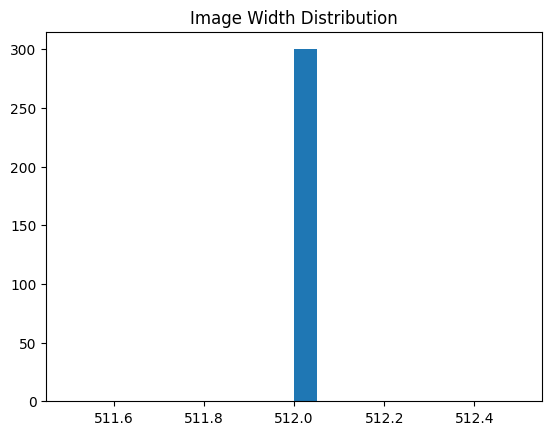

In [25]:
#resolution check for all fundus paths
sample_paths = df["fundus"].dropna().sample(300, random_state=42).tolist()

shapes = []
for p in sample_paths:
    img = read_image_from_zip(p)
    if img is not None:
        shapes.append(img.shape[:2])

shapes = np.array(shapes)

print("Unique heights:", np.unique(shapes[:,0]))
print("Unique widths:", np.unique(shapes[:,1]))

plt.figure()
plt.hist(shapes[:,0], bins=20)
plt.title("Image Height Distribution")
plt.show()

plt.figure()
plt.hist(shapes[:,1], bins=20)
plt.title("Image Width Distribution")
plt.show()


In [31]:
#visual inspection
%pip install qgrid    


Note: you may need to restart the kernel to use updated packages.


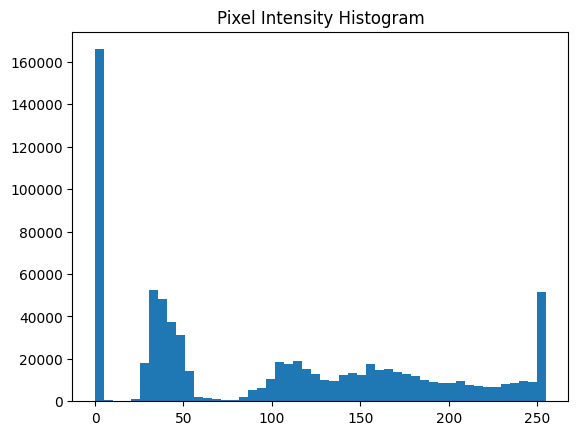

In [32]:
img = read_image_from_zip(df["fundus"].dropna().iloc[0])

plt.figure()
plt.hist(img.flatten(), bins=50)
plt.title("Pixel Intensity Histogram")
plt.show()


In [33]:
sample_paths = df["fundus"].dropna().sample(200, random_state=42).tolist()

means = []
stds = []

for p in sample_paths:
    img = read_image_from_zip(p)
    if img is not None:
        img = img.astype(np.float32) / 255.0
        means.append(img.mean(axis=(0,1)))
        stds.append(img.std(axis=(0,1)))

means = np.array(means)
stds = np.array(stds)

print("Dataset mean RGB:", means.mean(axis=0))
print("Dataset std  RGB:", stds.mean(axis=0))


Dataset mean RGB: [0.40990967 0.24348967 0.13916747]
Dataset std  RGB: [0.25622398 0.15764199 0.09339085]


Blur min/median/max: 9.607086037503905 69.800301584728 410.53645765093097


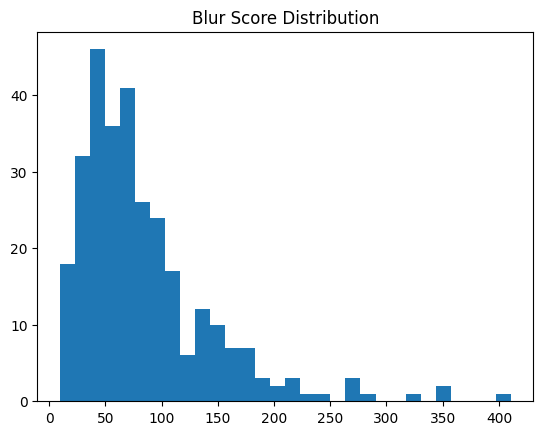

In [34]:
sample_paths = df["fundus"].dropna().sample(300, random_state=42).tolist()

blur_scores = []

for p in sample_paths:
    img = read_image_from_zip(p)
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        blur_scores.append(cv2.Laplacian(gray, cv2.CV_64F).var())

blur_scores = np.array(blur_scores)

print("Blur min/median/max:",
      blur_scores.min(),
      np.median(blur_scores),
      blur_scores.max())

plt.figure()
plt.hist(blur_scores, bins=30)
plt.title("Blur Score Distribution")
plt.show()


Normal Samples


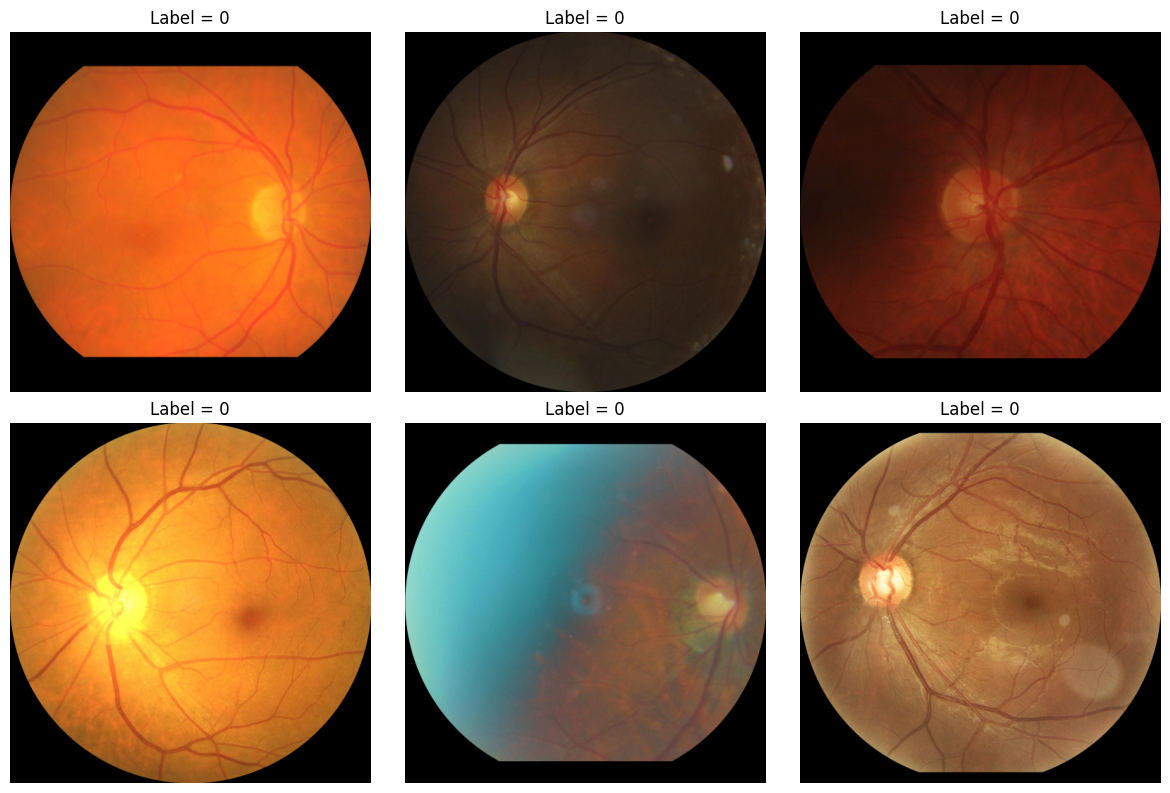

Glaucoma Samples


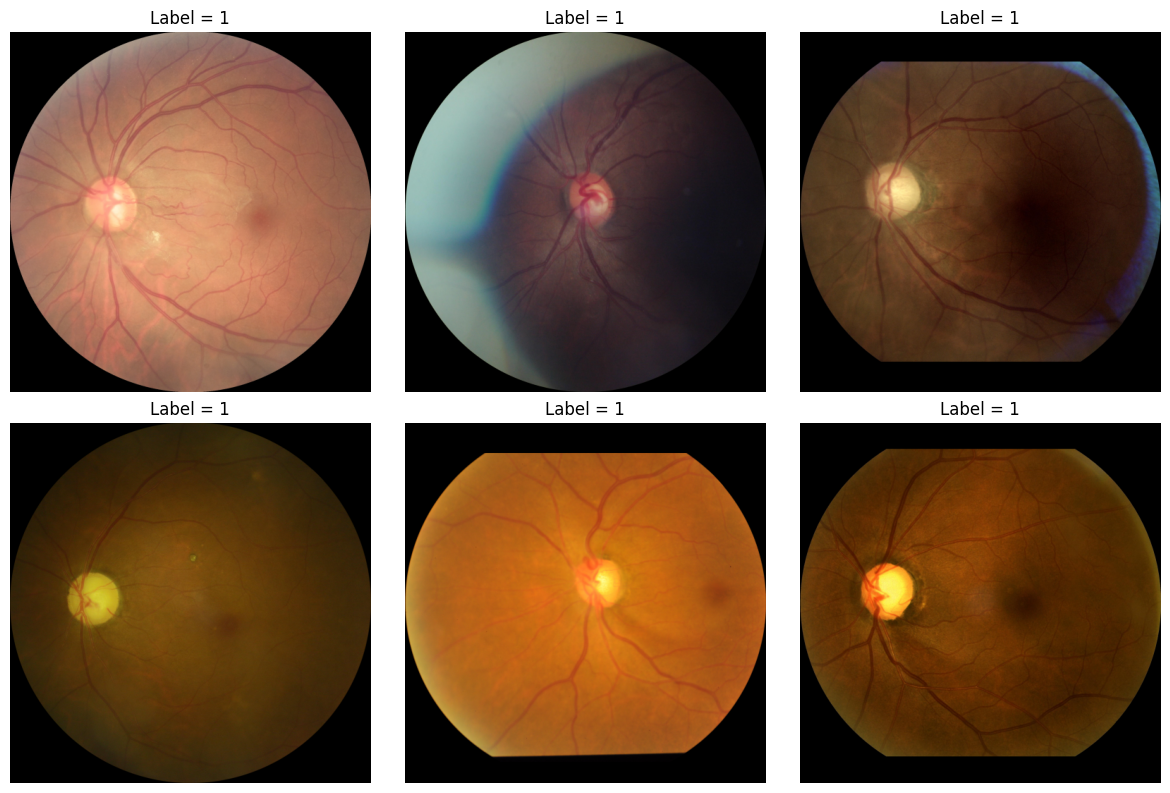

In [35]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(label, n=6, seed=42):
    subset = df[df["types"] == label].dropna(subset=["fundus"]).sample(n, random_state=seed)
    paths = subset["fundus"].tolist()

    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(12, 4 * rows))
    for i, p in enumerate(paths):
        img = read_image_from_zip(p)
        if img is None:
            continue
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Label = {label}")
    plt.tight_layout()
    plt.show()

print("Normal Samples")
show_samples(0)

print("Glaucoma Samples")
show_samples(1)
